# Capítulo 6: Predicción Directa — Serie Real vs. Predicha

## 6.1 Metodología

El **forecast directo** ajusta el modelo **una sola vez** sobre el conjunto de entrenamiento y proyecta los $h$ pasos al frente sin actualización:

$$[\hat{y}_{T+1}, \hat{y}_{T+2}, \ldots, \hat{y}_{T+h}] = \text{ARIMA.forecast}(h)$$

La incertidumbre se acumula con el horizonte: $\text{Var}(e_{T+k|T}) \geq \text{Var}(e_{T+1|T})$, por lo que las bandas de confianza se amplían progresivamente.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8F9FA',
                     'axes.grid':True,'grid.alpha':0.4,'font.size':11})

raw = yf.download('BTC-USD', start='2014-09-17',
                  end=datetime.today().strftime('%Y-%m-%d'), progress=False)
btc = raw[['Close']].copy()
btc.columns = ['Price']
btc.index = pd.DatetimeIndex(btc.index).normalize()
btc.dropna(inplace=True)

HORIZONTES = [7, 14, 21, 28]
N = len(btc)
splits = {h: {'train': btc.Price.iloc[:N-h],
              'test':  btc.Price.iloc[N-h:]} for h in HORIZONTES}
ORDERS_AIC = {7:(1,1,0), 14:(1,1,0), 21:(2,1,1), 28:(1,1,0)}
colors_h = ['#1E88E5','#43A047','#FB8C00','#E53935']

def direct_forecast(train_series, test_series, order):
    model_fit = ARIMA(train_series, order=order).fit()
    h  = len(test_series)
    fc = model_fit.get_forecast(steps=h)
    preds = fc.predicted_mean
    preds.index = test_series.index
    ci = fc.conf_int(alpha=0.05)
    ci.index = test_series.index
    ci.columns = ['lower_95','upper_95']
    return preds, ci

def metricas(y_real, y_pred):
    yr, yp = np.array(y_real), np.array(y_pred)
    return {'MAPE': np.mean(np.abs((yr-yp)/yr))*100,
            'MAE':  mean_absolute_error(yr,yp),
            'RMSE': np.sqrt(mean_squared_error(yr,yp)),
            'R2':   r2_score(yr,yp)}

print('Ejecutando direct forecasts...')
direct_results = {}
for h in HORIZONTES:
    preds, ci_df = direct_forecast(splits[h]['train'], splits[h]['test'], ORDERS_AIC[h])
    m = metricas(splits[h]['test'].values, preds.values)
    direct_results[h] = {'preds':preds,'ci':ci_df,'test':splits[h]['test'],'m':m}
    print(f'  H={h}d | ARIMA{ORDERS_AIC[h]} | MAPE={m["MAPE"]:.4f}% | R2={m["R2"]:.4f}')
print('Listo.')

Ejecutando direct forecasts...
  H=7d | ARIMA(1, 1, 0) | MAPE=1.1023% | R2=-0.5201
  H=14d | ARIMA(1, 1, 0) | MAPE=3.8201% | R2=-1.9594
  H=21d | ARIMA(2, 1, 1) | MAPE=3.5695% | R2=-0.3629
  H=28d | ARIMA(1, 1, 0) | MAPE=2.9704% | R2=-0.2053
Listo.


## 6.2 Serie Real vs. Predicha — Forecast Directo

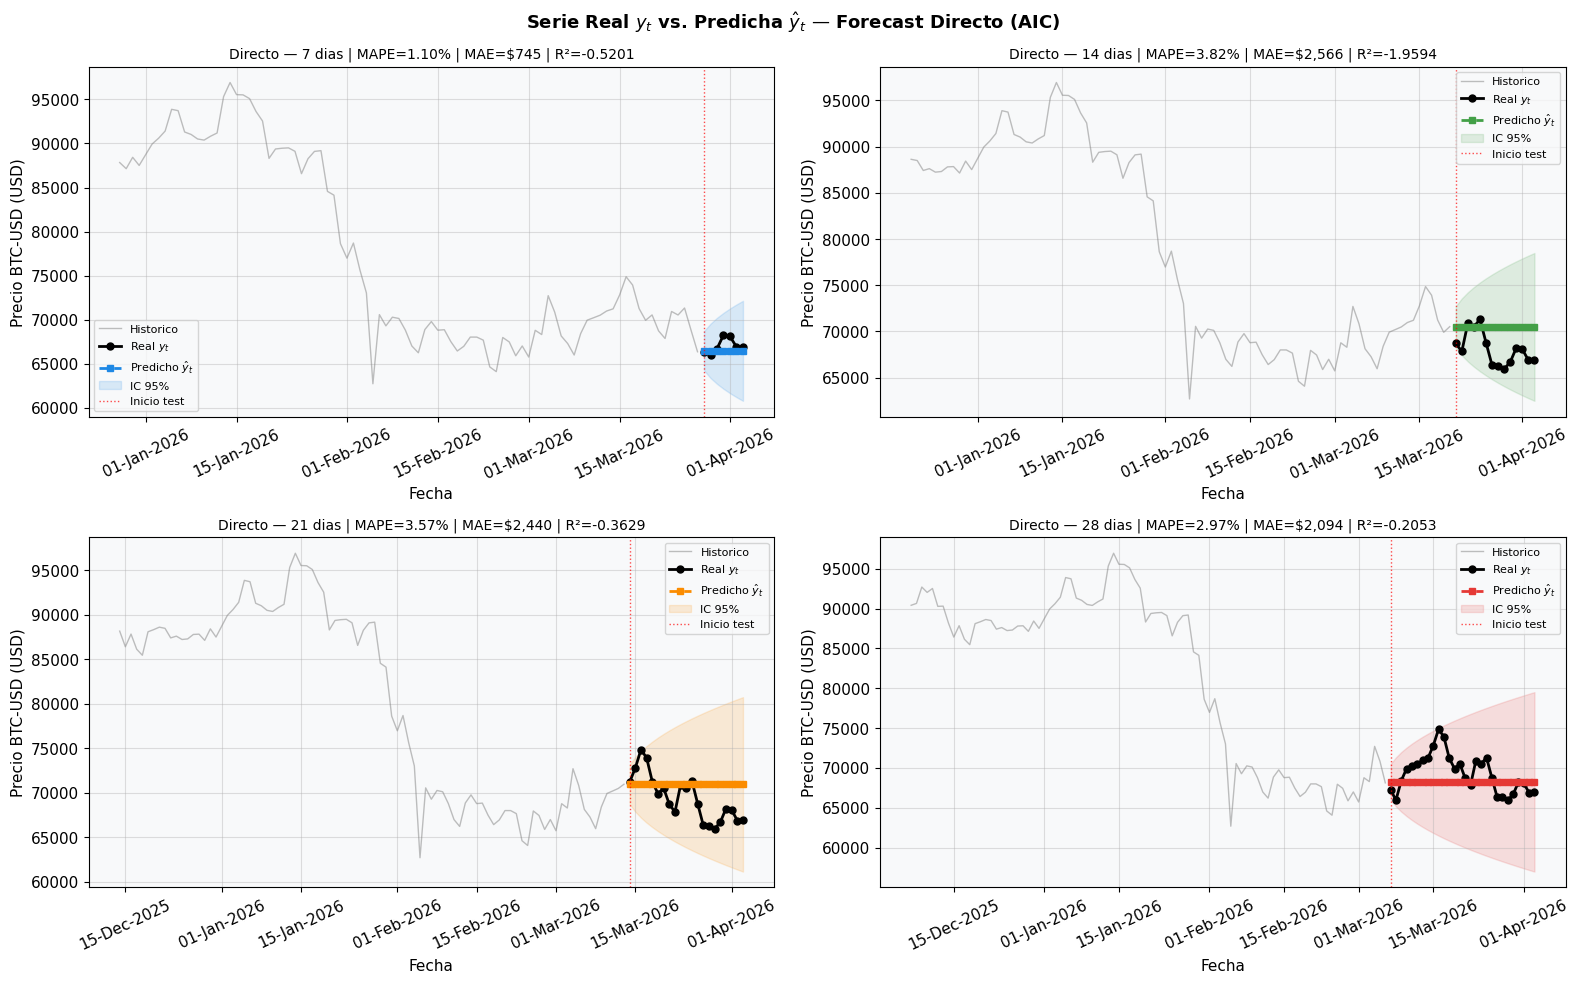

[Conclusion] El forecast directo tiende a la media de largo plazo a medida que aumenta el horizonte. Las bandas de IC se amplian notablemente. En horizontes largos (28d) el modelo casi no captura la variacion real.


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, h in enumerate(HORIZONTES):
    ax   = axes[i]
    res  = direct_results[h]
    test = res['test']
    pred = res['preds']
    ci   = res['ci']
    m    = res['m']
    ctx  = splits[h]['train'].iloc[-90:]

    ax.plot(ctx.index, ctx.values, color='gray', lw=1, alpha=0.5, label='Historico')
    ax.plot(test.index, test.values, color='black', lw=2,
            marker='o', ms=5, label='Real $y_t$')
    ax.plot(pred.index, pred.values, color=colors_h[i], lw=2, ls='--',
            marker='s', ms=5, label='Predicho $\\hat{y}_t$')
    ax.fill_between(ci.index, ci.lower_95, ci.upper_95,
                    color=colors_h[i], alpha=0.15, label='IC 95%')
    ax.axvline(test.index[0], color='red', lw=1, ls=':', alpha=0.7,
               label='Inicio test')

    ax.set_title(f'Directo — {h} dias | MAPE={m["MAPE"]:.2f}% | '
                 f'MAE=${m["MAE"]:,.0f} | R²={m["R2"]:.4f}', fontsize=10)
    ax.set_ylabel('Precio BTC-USD (USD)')
    ax.set_xlabel('Fecha')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Serie Real $y_t$ vs. Predicha $\\hat{y}_t$ — Forecast Directo (AIC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_direct_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Conclusion] El forecast directo tiende a la media de largo plazo a '
      'medida que aumenta el horizonte. Las bandas de IC se amplian notablemente. '
      'En horizontes largos (28d) el modelo casi no captura la variacion real.')

## 6.3 Correlacion $\\text{Corr}(y_t, \\hat{y}_t)$ — Forecast Directo

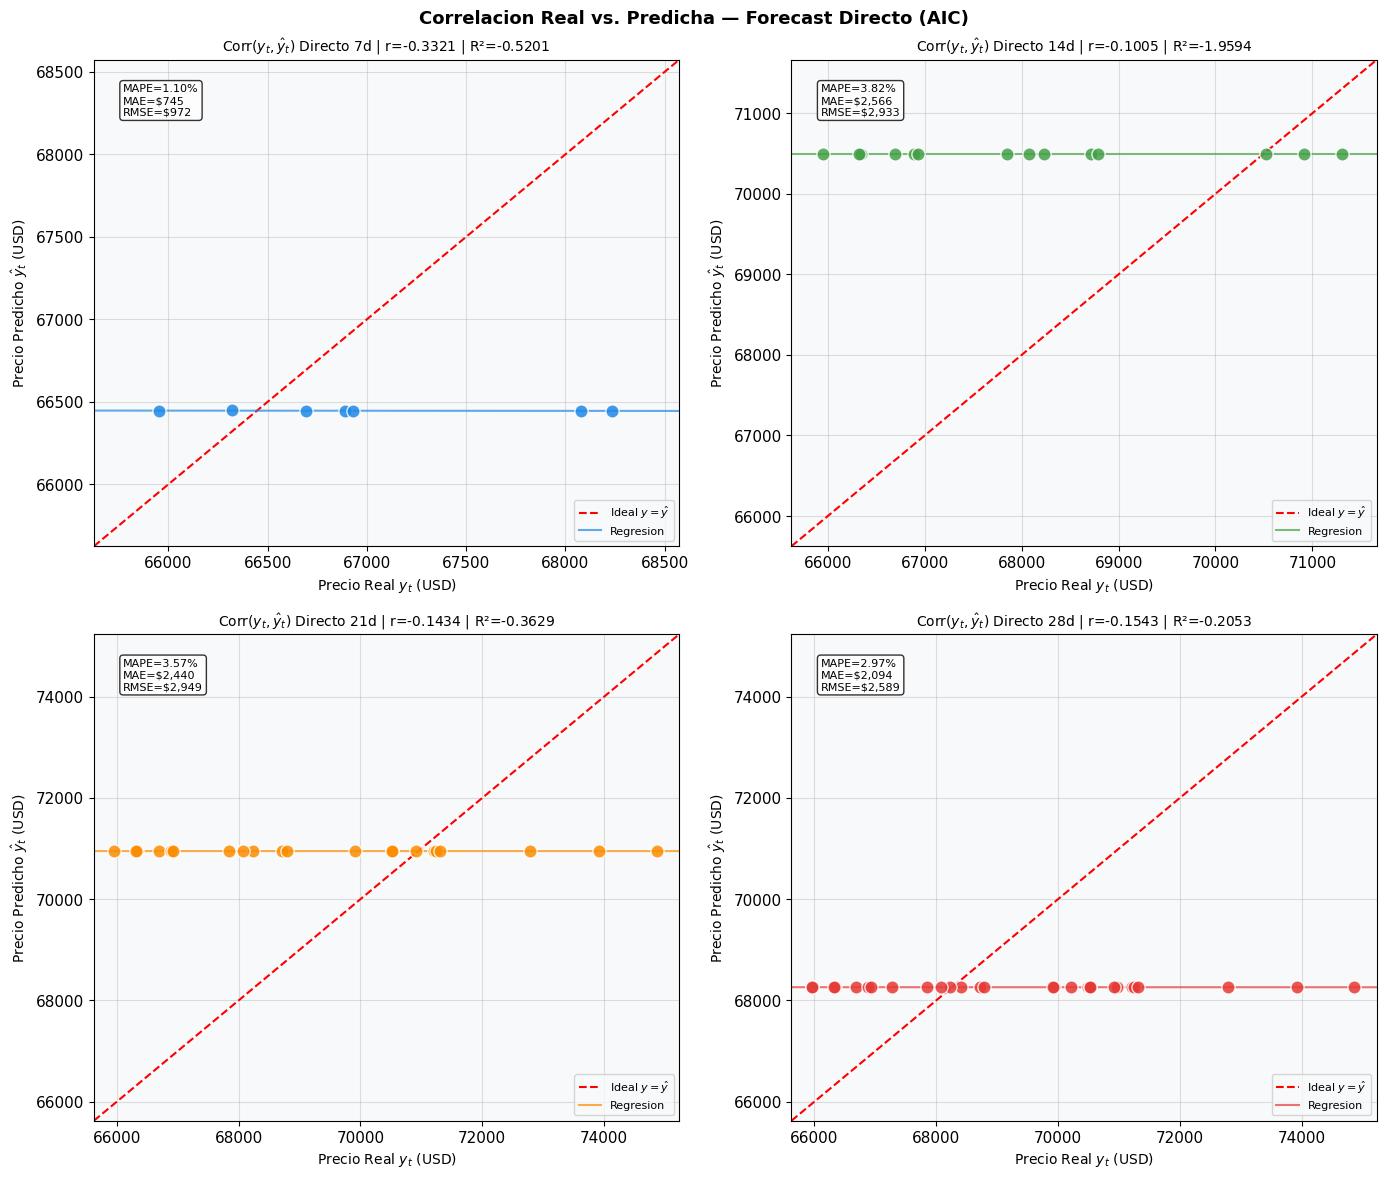

[Conclusion] Los graficos de correlacion del forecast directo muestran predicciones casi constantes (horizontal) porque ARIMA converge a la media incondicional. El R2 negativo en varios horizontes confirma que el modelo directo es peor predictor que la simple media historica.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, h in enumerate(HORIZONTES):
    ax    = axes[i]
    res   = direct_results[h]
    yreal = res['test'].values
    ypred = res['preds'].values
    m     = res['m']
    corr  = np.corrcoef(yreal, ypred)[0,1]

    ax.scatter(yreal, ypred, color=colors_h[i],
               alpha=0.85, edgecolors='white', s=90, zorder=3)

    lims = [min(yreal.min(),ypred.min())*0.995,
            max(yreal.max(),ypred.max())*1.005]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal $y=\\hat{y}$')

    z = np.polyfit(yreal, ypred, 1)
    x_line = np.linspace(lims[0], lims[1], 100)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color=colors_h[i], lw=1.5, alpha=0.7, label='Regresion')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Precio Real $y_t$ (USD)', fontsize=10)
    ax.set_ylabel('Precio Predicho $\\hat{y}_t$ (USD)', fontsize=10)
    ax.set_title(f'Corr$(y_t,\\hat{{y}}_t)$ Directo {h}d | '
                 f'r={corr:.4f} | R²={m["R2"]:.4f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.95,
            f'MAPE={m["MAPE"]:.2f}%\nMAE=${m["MAE"]:,.0f}\nRMSE=${m["RMSE"]:,.0f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Correlacion Real vs. Predicha — Forecast Directo (AIC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_direct_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Conclusion] Los graficos de correlacion del forecast directo muestran '
      'predicciones casi constantes (horizontal) porque ARIMA converge a la '
      'media incondicional. El R2 negativo en varios horizontes confirma que '
      'el modelo directo es peor predictor que la simple media historica.')

:::{admonition} Conclusion — Forecast Directo
:class: tip

El forecast directo produce predicciones que convergen rapidamente a la media incondicional del proceso. Esto es coherente con la teoria: para un proceso I(1), la mejor prediccion sin informacion adicional es el ultimo valor observado (caminata aleatoria), y la proyeccion de $h$ pasos tiende a la media de la serie diferenciada. El $R^2$ negativo en horizontes largos evidencia que el modelo estatico es inferior a la media como predictor, justificando el uso del metodo rolling para aplicaciones practicas.
:::